# EDA template

**Copy this file to `eda-<yourname>.ipynb` before you start working in it.**
One notebook per person — merging two people's edits to the same `.ipynb`
means resolving conflicts in JSON with embedded outputs.

Clear outputs before committing.

## Setup

Paths come from the package, not from relative `../data/...` strings, so every
cell works no matter which directory the kernel was started in.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from un_general_debate_analysis.preprocessing import (
    OUT_DIR,
    META_COLUMNS,
    merge_country_year,
    sentence_count_columns,
)
from un_general_debate_analysis.lexicons import LEXICONS

# speeches_features.csv is 56 columns wide
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(f"reading from {OUT_DIR}")
print(f"lexicons: {list(LEXICONS)}")

reading from /Users/georgemimoglou/Projects/uva/UN-General-Debate-Analysis/data/processed
lexicons: ['theme_trust', 'theme_transformation', 'theme_multilateralism', 'sdg04_education', 'sdg05_gender_equality', 'sdg08_decent_work', 'sdg09_industry_innovation', 'sdg16_peace_justice', 'sdg17_partnerships']


## Load the data

`features` is the main table: one row per speech (= one country-year), with
metadata, text statistics, VADER sentiment, and four columns per lexicon.

`terms` is long — one row per (year, lexicon, term) — and shows *which* words
drive a trend.

In [2]:
features = pd.read_csv(OUT_DIR / "speeches_features.csv")
terms = pd.read_csv(OUT_DIR / "lexicon_terms_by_year.csv")

print(f"features: {features.shape[0]:,} speeches x {features.shape[1]} columns")
print(f"terms:    {terms.shape[0]:,} rows")
print(f"years:    {features['year'].min()}-{features['year'].max()}")

# Sanity check: the full corpus is ~11k speeches. Many fewer means someone ran
# the pipeline with --limit; re-run it without one.
if len(features) < 10_000:
    print(f"\nWARNING: only {len(features):,} speeches — looks like a --limit sample.")

features: 200 speeches x 56 columns
terms:    2,638 rows
years:    1946-2025



In [3]:
features.head()

,country_code,country,year,session,region_name,sub_region_name,speaker_name,speaker_post,speaker_role,n_sentences,n_words,n_unique_lemmas,lexical_density,mean_sentence_length,sentiment_compound_mean,share_positive_sentences,share_negative_sentences,n_positive_sentences,n_negative_sentences,theme_trust_count,theme_trust_positive_sentences,theme_trust_negative_sentences,theme_trust_sentences,theme_transformation_count,theme_transformation_positive_sentences,theme_transformation_negative_sentences,theme_transformation_sentences,theme_multilateralism_count,theme_multilateralism_positive_sentences,theme_multilateralism_negative_sentences,theme_multilateralism_sentences,sdg04_education_count,sdg04_education_positive_sentences,sdg04_education_negative_sentences,sdg04_education_sentences,sdg05_gender_equality_count,sdg05_gender_equality_positive_sentences,sdg05_gender_equality_negative_sentences,sdg05_gender_equality_sentences,sdg08_decent_work_count,sdg08_decent_work_positive_sentences,sdg08_decent_work_negative_sentences,sdg08_decent_work_sentences,sdg09_industry_innovation_count,sdg09_industry_innovation_positive_sentences,sdg09_industry_innovation_negative_sentences,sdg09_industry_innovation_sentences,sdg16_peace_justice_count,sdg16_peace_justice_positive_sentences,sdg16_peace_justice_negative_sentences,sdg16_peace_justice_sentences,sdg17_partnerships_count,sdg17_partnerships_positive_sentences,sdg17_partnerships_negative_sentences,sdg17_partnerships_sentences,term_counts
0,TUR,Türkiye,1946,1,Asia,Western Asia,Mr. Baydur,NaN,unknown,34,624,286,0.482372,18.352941,0.283050,0.558824,0.176471,19,6,0,0,0,0,1,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,4,0,6,0,0,0,0,"{""charter"": 1, ""justice"": 3, ""peace"": 2, ""tran..."
1,NLD,Netherlands (Kingdom of the),1948,3,Europe,Western Europe,Mr. VAN ROIJEN,NaN,unknown,94,3090,849,0.520065,32.872340,0.404567,0.755319,0.159574,71,15,0,0,0,0,1,0,1,1,12,10,1,11,0,0,0,0,0,0,0,0,1,1,0,1,1,0,1,1,29,20,4,25,1,1,0,1,"{""charter"": 6, ""conflict"": 3, ""democratic"": 3,..."
2,RUS,Russian Federation,1948,3,Europe,Eastern Europe,Mr. VYSHINSKY,NaN,unknown,189,6749,1281,0.523040,35.708995,0.097817,0.513228,0.386243,97,73,1,1,0,1,0,0,0,0,20,8,4,12,0,0,0,0,0,0,0,0,6,3,3,6,4,1,3,4,119,26,46,74,3,2,1,3,"{""aid"": 3, ""charter"": 4, ""democracy"": 12, ""dem..."
3,VEN,Venezuela (Bolivarian Republic of),1949,4,Americas,Latin America and the Caribbean,Mr. STOLK,NaN,unknown,55,1861,619,0.533584,33.836364,0.281556,0.636364,0.272727,35,15,2,1,1,2,0,0,0,0,15,10,2,14,1,1,0,1,0,0,0,0,2,2,0,2,0,0,0,0,24,16,3,19,0,0,0,0,"{""charter"": 11, ""confidence"": 1, ""conflict"": 1..."
4,HTI,Haiti,1951,6,Americas,Latin America and the Caribbean,Mr. BELLEGARDE,NaN,unknown,60,2492,840,0.521268,41.533333,0.205385,0.566667,0.333333,34,20,1,1,0,1,0,0,0,0,6,4,2,6,2,1,1,2,1,1,0,1,1,1,0,1,0,0,0,0,42,14,10,25,1,1,0,1,"{""aid"": 1, ""charter"": 1, ""democracy"": 6, ""demo..."


### The text, loaded separately

`speeches_text.csv.gz` holds the cleaned text and the lemmatised, stop-word-free
tokens of every speech. It is a few hundred MB in memory for the full corpus, so
only load it when you actually need it (TF-IDF, topic models, word clouds).

In [4]:
# texts = pd.read_csv(OUT_DIR / "speeches_text.csv.gz")
# texts.head()

### `term_counts` is a JSON string

Parse it with `json.loads` (not `ast.literal_eval`) to get the per-term counts
for a single speech.

In [5]:
example = features.iloc[0]
print(f"{example['country']}, {example['year']}")
json.loads(example["term_counts"])

Türkiye, 1946


{'charter': 1, 'justice': 3, 'peace': 2, 'transition': 1, 'weapon': 1}

## Normalise before comparing

Speech length varies enormously across the corpus, and so does the number of
countries speaking each year (~50 in 1946, ~190 today). Raw counts are not
comparable across speeches or across years — always divide first.

- word counts (`<lexicon>_count`) by `n_words`
- sentence counts (`<lexicon>_sentences`) by `n_sentences`

In [6]:
rates = features[META_COLUMNS[:4]].copy()
for lexicon in LEXICONS:
    rates[f"{lexicon}_per_1k_words"] = (
        1_000 * features[f"{lexicon}_count"] / features["n_words"]
    )

rates.groupby("year")[[f"{lex}_per_1k_words" for lex in LEXICONS]].mean().tail()

,theme_trust_per_1k_words,theme_transformation_per_1k_words,theme_multilateralism_per_1k_words,sdg04_education_per_1k_words,sdg05_gender_equality_per_1k_words,sdg08_decent_work_per_1k_words,sdg09_industry_innovation_per_1k_words,sdg16_peace_justice_per_1k_words,sdg17_partnerships_per_1k_words
year,,,,,,,,,
2021,3.105590,3.726708,2.484472,0.000000,3.726708,0.000000,1.242236,11.801242,0.000000
2022,0.619784,2.727315,2.745989,2.287397,0.726824,0.667157,0.524545,10.437375,2.601810
2023,2.763028,1.732218,4.236418,1.381643,1.703816,0.505443,2.162218,11.103438,4.400118
2024,1.805579,8.674227,8.369085,0.538492,0.260203,0.773983,1.966598,14.430571,3.434597
2025,1.460484,2.712560,7.301016,0.289017,0.578035,0.289017,1.923873,15.213256,2.693352


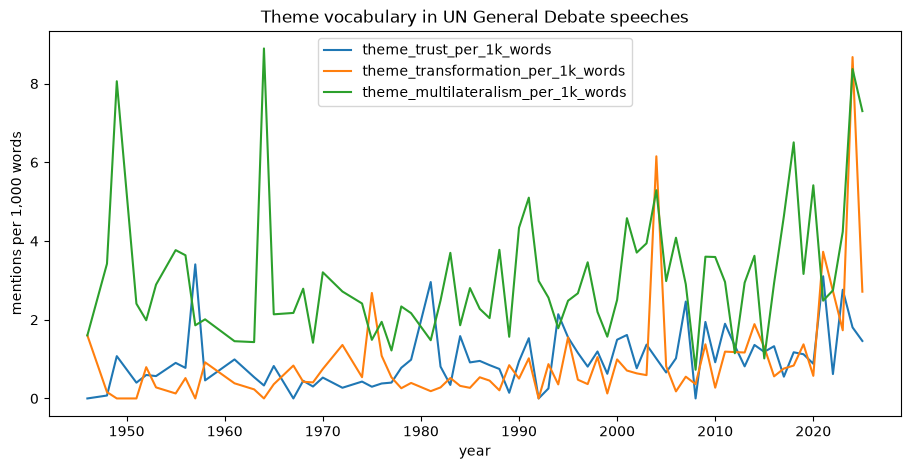

In [7]:
# A first look: how much the themes are talked about over time
yearly = rates.groupby("year")[
    ["theme_trust_per_1k_words", "theme_transformation_per_1k_words",
     "theme_multilateralism_per_1k_words"]
].mean()

yearly.plot(figsize=(11, 5))
plt.ylabel("mentions per 1,000 words")
plt.xlabel("year")
plt.title("Theme vocabulary in UN General Debate speeches")
plt.show()

## Bringing in an external dataset

`merge_country_year` joins on `(country_code, year)` with ISO-3166 alpha-3 codes.
Its defaults match Our World in Data exports (`Entity`, `Code`, `Year`); pass
`country_col` / `year_col` for anything else.

Remember the corpus contains states that no longer exist (`CSK`, `DDR`, `YUG`,
`YMD`) plus `EU`, which external datasets usually lack — expect NaNs there.

In [8]:
# owid = pd.read_csv("../data/external/some-indicator.csv")
# df = merge_country_year(features, owid)
#
# happiness = pd.read_csv("../data/external/happiness.csv")
# df = merge_country_year(features, happiness, country_col="iso3", year_col="year")
#
# print(f"matched {df['<indicator>'].notna().sum():,} of {len(df):,} speeches")

## Your analysis below

Two reminders from the brief:

- Session 80 (2025) was transcribed from interpretation audio, not official
  transcripts. Be careful reading a 2025 "trend" as real.
- `speaker_role` is `unknown` for many pre-1994 speeches; the UN records do not
  consistently give the speaker's post before then.